# Standard Stars and CalSpec

Standard stars are essential for flux calibration of IFS observations.
`slicersim` provides direct access to the HST **CalSpec** catalog through `LazuliCalSpec`,
letting you simulate observations of any catalog star and estimate the required exposure time
for a given calibration quality.

This notebook shows:
- How to load a CalSpec star by name
- How to inspect and plot its spectrum
- How to set observing conditions and get a realistic simulated spectrum
- How to compare several standard stars

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

***
## 1. Loading a star and listing available CalSpec sources

Pass any short name to `LazuliCalSpec`. The `source_names` property on the instance
lists all 161 unique stars in the catalog.

In [2]:
# Load the white dwarf GD71 — a classic flux calibrator
star = slicersim.LazuliCalSpec("gd71")

# List available names (property on instance)
names = list(dict.fromkeys(star.source_names))  # unique names
print(f"{len(names)} stars available. First 20:")
print(names[:20])

161 stars available. First 20:
['109vir', '10lac', '16cygb', '1732526', '1740346', '1743045', '1757132', '1802271', '1805292', '1808347', '1812095', '1812524', '18sco', '2m003618', '2m055914', '', 'agk_81d266', 'alpha_lyr', 'bd02d3375', 'bd11d3759']


***
## 2. Inspecting the spectrum

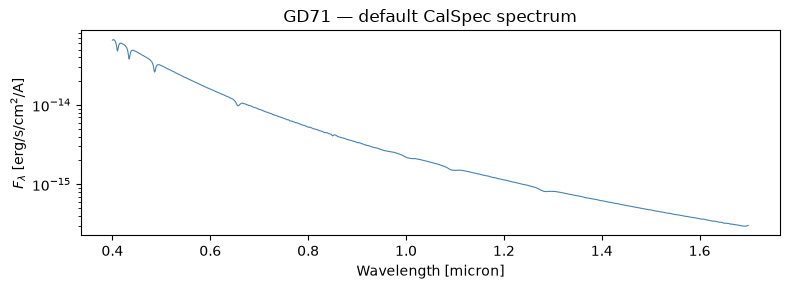

In [3]:
# Default spectrum (no noise, flux-calibrated)
lbda, flux, variance = star.get_spectrum(unit="flambda", incl_error=False)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(lbda / 1e4, flux, lw=0.8, color="steelblue")
ax.set_xlabel("Wavelength [micron]")
ax.set_ylabel(r"$F_\lambda$ [erg/s/cm$^2$/A]")
ax.set_title("GD71 — default CalSpec spectrum")
ax.set_yscale("log")
plt.tight_layout()

***
## 3. Setting the apparent magnitude

CalSpec spectra are stored at their true HST-measured flux level.
Use `change_properties()` to rescale to any apparent magnitude —
useful for modelling a calibrator of a given field brightness.

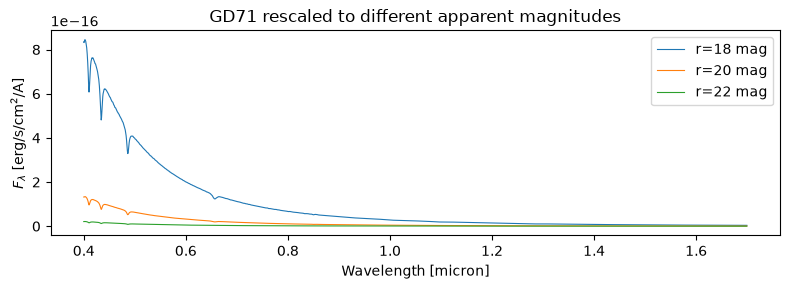

In [4]:
fig, ax = plt.subplots(figsize=(8, 3))

for mag in [18, 20, 22]:
    star.change_properties(mag=mag, band="sdssr")
    lbda, flux, _ = star.get_spectrum(unit="flambda", incl_error=False)
    ax.plot(lbda / 1e4, flux, lw=0.8, label=f"r={mag} mag")

ax.set_xlabel("Wavelength [micron]")
ax.set_ylabel(r"$F_\lambda$ [erg/s/cm$^2$/A]")
ax.set_title("GD71 rescaled to different apparent magnitudes")
ax.legend()
plt.tight_layout()

***
## 4. Exposure time for a calibration observation

How long does it take to get a well-calibrated spectrum of a faint standard?
We target SNR=50 per resolution element, which is typical for a useful flux calibrator.

In [5]:
# Rescale to mag=20 in sdss-r
star.change_properties(mag=20, band="sdssr")

_ = star.setup_to_snr(50, per_resolution=True, lbda_range=[6000, 9000])

exptime = star.get_exposure_time()
cfg = star.get_readout_config()
print(f"Exposure time : {exptime:.1f} s  ({exptime/60:.1f} min)")
print(f"Readout mode  : nmd={cfg['nmd']},  nramps={cfg['nramps']}")

Exposure time : 633.9 s  (10.6 min)
Readout mode  : nmd=(28, 8, 0),  nramps=1


***
## 5. Realistic simulated spectrum

Once the readout is configured, `get_spectrum()` returns the flux and its variance.
Drawing a realisation gives you what the pipeline would actually receive.

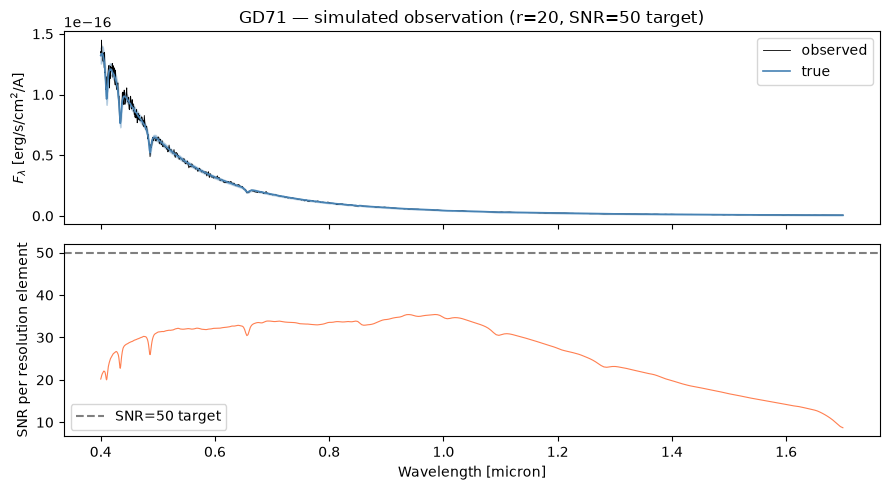

In [6]:
lbda, flux_true, variance = star.get_spectrum(unit="flambda", incl_error=False)
flux_obs = np.random.normal(loc=flux_true, scale=np.sqrt(variance))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

ax1.plot(lbda / 1e4, flux_obs, lw=0.6, color="k", label="observed")
ax1.plot(lbda / 1e4, flux_true, lw=1.2, color="steelblue", label="true")
ax1.fill_between(lbda / 1e4,
                 flux_true - np.sqrt(variance),
                 flux_true + np.sqrt(variance),
                 alpha=0.3, color="steelblue")
ax1.set_ylabel(r"$F_\lambda$ [erg/s/cm$^2$/A]")
ax1.legend()
ax1.set_title("GD71 — simulated observation (r=20, SNR=50 target)")

snr = flux_true / np.sqrt(variance)
ax2.plot(lbda / 1e4, snr, lw=0.8, color="coral")
ax2.axhline(50, ls="--", color="k", alpha=0.5, label="SNR=50 target")
ax2.set_xlabel("Wavelength [micron]")
ax2.set_ylabel("SNR per resolution element")
ax2.legend()

plt.tight_layout()

***
## 6. Comparing several standard stars

Different CalSpec stars have very different spectral shapes. Here we compare a
hot white dwarf (GD71), a G-type standard (P177D), and the DA white dwarf Feige 110.

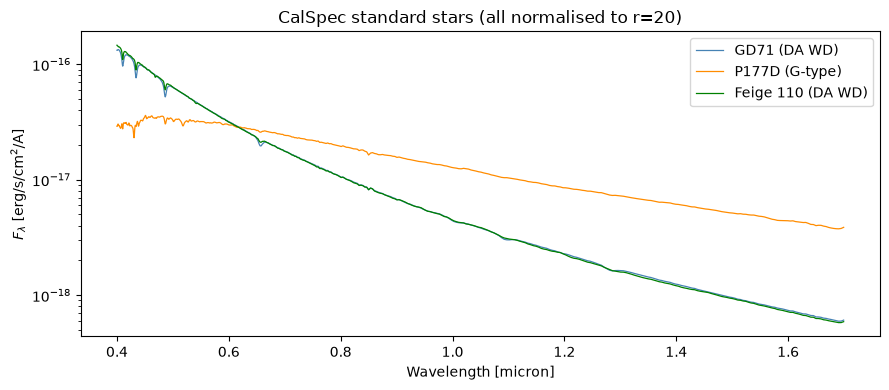

In [7]:
star_names = ["gd71", "p177d", "feige110"]
labels     = ["GD71 (DA WD)", "P177D (G-type)", "Feige 110 (DA WD)"]
colors     = ["steelblue", "darkorange", "green"]

fig, ax = plt.subplots(figsize=(9, 4))

for name, label, color in zip(star_names, labels, colors):
    s = slicersim.LazuliCalSpec(name)
    # normalise to r=20 for a fair spectral-shape comparison
    s.change_properties(mag=20, band="sdssr")
    lbda, flux, _ = s.get_spectrum(unit="flambda", incl_error=False)
    ax.plot(lbda / 1e4, flux, lw=0.9, color=color, label=label)

ax.set_xlabel("Wavelength [micron]")
ax.set_ylabel(r"$F_\lambda$ [erg/s/cm$^2$/A]")
ax.set_title("CalSpec standard stars (all normalised to r=20)")
ax.legend()
ax.set_yscale("log")
plt.tight_layout()

Hot DA white dwarfs like GD71 and Feige 110 are featureless and blue, making them ideal
calibrators for Lazuli because they deliver high flux across the full instrument wavelength range.

***
## 7. Exposure-time grid as a function of magnitude

A quick scan to understand the calibration overhead for standards of different brightnesses.

CPU times: user 4.04 s, sys: 1.39 s, total: 5.43 s
Wall time: 5.47 s


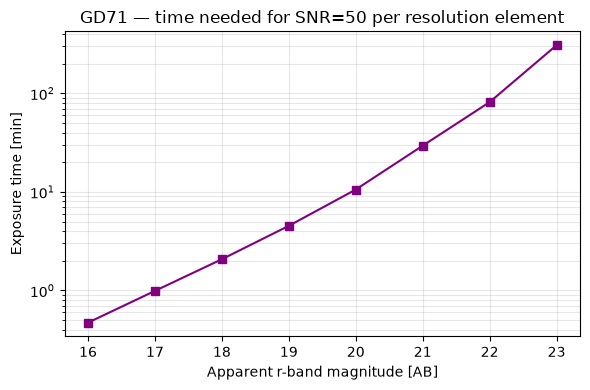

In [8]:
%%time
mags = np.arange(16, 24)
exptimes = []

for mag in mags:
    s = slicersim.LazuliCalSpec("gd71")
    s.change_properties(mag=float(mag), band="sdssr")
    _ = s.setup_to_snr(50, per_resolution=True, lbda_range=[6000, 9000])
    exptimes.append(s.get_exposure_time() / 60)  # minutes

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(mags, exptimes, "s-", color="purple")
ax.set_xlabel("Apparent r-band magnitude [AB]")
ax.set_ylabel("Exposure time [min]")
ax.set_title("GD71 — time needed for SNR=50 per resolution element")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()